# The Blockbuster Formula
### Bayesian Network Analysis of Box Office Success (2000–2025)

## Section 0 - Setup & Imports

In [12]:
import os
import re
import time
import warnings
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from pathlib import Path
from dotenv import load_dotenv
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup

# pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, PC, BIC
from pgmpy.inference import VariableElimination
import pgmpy

# sklearn
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
    multilabel_confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Paths
DATA_PATH    = Path('data')
OUTPUTS_PATH = Path('outputs')
DATA_PATH.mkdir(exist_ok=True)
OUTPUTS_PATH.mkdir(exist_ok=True)

# Colour palette used across all plots
OUTCOME_COLORS = {
    'Flop':        '#e74c3c',
    'Break-even':  '#f39c12',
    'Hit':         '#2ecc71',
    'Blockbuster': '#2980b9',
}
outcome_order = ['Flop', 'Break-even', 'Hit', 'Blockbuster']

# API
load_dotenv()
TMDB_API_KEY = os.getenv('TMDB_API_KEY')
if not TMDB_API_KEY:
    raise ValueError('TMDb API key not found. Add TMDB_API_KEY to your .env file.')

print(f'pgmpy {pgmpy.__version__} | pandas {pd.__version__} | numpy {np.__version__}')
print('All imports OK.')

pgmpy 1.1.0 | pandas 2.2.3 | numpy 2.2.3
All imports OK.


## Section 1 - Data Collection

In [13]:
# TMDb API config and helper
TMDB_BASE    = 'https://api.themoviedb.org/3'
TMDB_HEADERS = {'accept': 'application/json'}
START_YEAR   = 2000
END_YEAR     = 2025
PAGES_PER_YEAR = 10
REQUEST_DELAY  = 0.25

RAW_PATH  = DATA_PATH / 'movies_raw_v2.csv'
SUPP_PATH = DATA_PATH / 'numbers_supplement_v2.csv'
FEAT_PATH = DATA_PATH / 'movies_featured_v2.csv'

def tmdb_get(endpoint, params=None):
    url = f'{TMDB_BASE}/{endpoint}'
    all_params = {'api_key': TMDB_API_KEY}
    if params:
        all_params.update(params)
    try:
        r = requests.get(url, headers=TMDB_HEADERS, params=all_params, timeout=10)
        r.raise_for_status()
        return r.json()
    except requests.exceptions.RequestException as e:
        print(f'Request failed for {endpoint}: {e}')
        return None

test = tmdb_get('configuration')
print('TMDb connection:', 'OK' if test else 'FAILED -- check API key')


TMDb connection: OK


In [9]:
# Smart loader -- skip API calls if raw data already exists
if RAW_PATH.exists():
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['release_date'])
    print(f'Raw data already exists -- loaded {len(df_raw)} rows from {RAW_PATH}')
    print(f'Date range: {df_raw["release_date"].min().year} - {df_raw["release_date"].max().year}')
    print('Skip to the Numbers supplement cell below.')
else:
    print(f'{RAW_PATH} not found -- run the cells below to fetch from TMDb.')
    df_raw = None


data\movies_raw_v2.csv not found -- run the cells below to fetch from TMDb.


In [14]:
# Step 1: Discover movie IDs per year -- skip if raw data already loaded
if df_raw is not None:
    print('Raw data already loaded -- skipping.')
else:
    def discover_ids(year, pages=PAGES_PER_YEAR):
        ids = []
        for page in range(1, pages + 1):
            data = tmdb_get('discover/movie', params={
                'primary_release_year': year, 'sort_by': 'popularity.desc',
                'include_adult': False, 'include_video': False,
                'page': page, 'language': 'en-US', 'with_original_language': 'en',
            })
            if data and 'results' in data:
                ids.extend([m['id'] for m in data['results']])
            time.sleep(REQUEST_DELAY)
        return ids

    print(f'Discovering IDs {START_YEAR} - {END_YEAR}...')
    all_ids = []
    for year in tqdm(range(START_YEAR, END_YEAR + 1), desc='Years'):
        all_ids.extend(discover_ids(year))
    all_ids = list(set(all_ids))
    print(f'Unique IDs collected: {len(all_ids)}')


Discovering IDs 2000 - 2025...


Years:   0%|          | 0/26 [00:00<?, ?it/s]

Unique IDs collected: 4741


In [15]:
# Step 2: Fetch details + credits -- skip if raw data already loaded
if df_raw is not None:
    print('Raw data already loaded -- skipping.')
else:
    def fetch_details(movie_id):
        details = tmdb_get(f'movie/{movie_id}', params={'language': 'en-US'})
        if not details:
            return None
        credits = tmdb_get(f'movie/{movie_id}/credits', params={'language': 'en-US'})
        cast_list, cast_ids = [], []
        if credits and 'cast' in credits:
            top = sorted(credits['cast'], key=lambda x: x.get('order', 99))[:5]
            cast_list = [c['name'] for c in top]
            cast_ids  = [str(c['id']) for c in top]
        return {
            'tmdb_id': movie_id,
            'title': details.get('title', ''),
            'release_date': details.get('release_date', ''),
            'genres': '|'.join(g['name'] for g in details.get('genres', [])),
            'budget': details.get('budget', 0),
            'revenue': details.get('revenue', 0),
            'runtime': details.get('runtime', 0),
            'popularity': details.get('popularity', 0),
            'vote_average': details.get('vote_average', 0),
            'vote_count': details.get('vote_count', 0),
            'original_language': details.get('original_language', ''),
            'cast_names': '|'.join(cast_list),
            'cast_ids':   '|'.join(cast_ids),
        }

    print(f'Fetching details for {len(all_ids)} movies...')
    movies, failed = [], []
    for mid in tqdm(all_ids, desc='Movies'):
        rec = fetch_details(mid)
        if rec: movies.append(rec)
        else:   failed.append(mid)
        time.sleep(REQUEST_DELAY)   
    print(f'Fetched: {len(movies)}  |  Failed: {len(failed)}')


Fetching details for 4741 movies...


Movies:   0%|          | 0/4741 [00:00<?, ?it/s]

Fetched: 4741  |  Failed: 0


In [16]:
# Step 3: Build DataFrame and save
if df_raw is not None:
    print('Raw data already loaded -- skipping build.')
else:
    df_raw = pd.DataFrame(movies)
    df_raw['release_date'] = pd.to_datetime(df_raw['release_date'], errors='coerce')
    df_raw['release_year'] = df_raw['release_date'].dt.year
    df_raw.to_csv(RAW_PATH, index=False)
    print(f'Saved {len(df_raw)} rows to {RAW_PATH}')

print(f'Shape: {df_raw.shape}')
df_raw.head(3)


Saved 4741 rows to data\movies_raw_v2.csv
Shape: (4741, 14)


,tmdb_id,title,release_date,genres,budget,revenue,runtime,popularity,vote_average,vote_count,original_language,cast_names,cast_ids,release_year
0,8193,Napoleon Dynamite,2004-06-11,Comedy,400000,46118097,95,3.4054,6.783,2127,en,Jon Heder|Efren Ramirez|Tina Majorino|Aaron Ru...,53926|20190|53930|53927|9629,2004
1,8198,The Quiet American,2002-11-22,Romance|Thriller|Drama|War,30000000,27674124,101,1.5456,6.545,325,en,Michael Caine|Brendan Fraser|Đỗ Thị Hải Yến|Tz...,3895|18269|53962|21629|1118,2002
2,614409,To All the Boys: Always and Forever,2021-02-12,Romance|Comedy|Drama,0,0,114,2.8253,7.502,2054,en,Lana Condor|Noah Centineo|Janel Parrish|Anna C...,1452046|1253353|93377|1683266|1299232,2021


In [17]:
# Raw data overview
print('=== Raw Data Summary ===')
print(f'Total rows:         {len(df_raw)}')
print(f'Budget  > 0:        {(df_raw["budget"] > 0).sum()}')
print(f'Revenue > 0:        {(df_raw["revenue"] > 0).sum()}')
print(f'Both zero:          {((df_raw["budget"]==0) & (df_raw["revenue"]==0)).sum()}')
print(f'Date range:         {df_raw["release_date"].min().date()} to {df_raw["release_date"].max().date()}')
bnz = df_raw[df_raw['budget']  > 0]['budget']
rnz = df_raw[df_raw['revenue'] > 0]['revenue']
print(f'Budget  min/med/max: ${bnz.min():,.0f} / ${bnz.median():,.0f} / ${bnz.max():,.0f}')
print(f'Revenue min/med/max: ${rnz.min():,.0f} / ${rnz.median():,.0f} / ${rnz.max():,.0f}')


=== Raw Data Summary ===
Total rows:         4741
Budget  > 0:        3551
Revenue > 0:        3599
Both zero:          869
Date range:         2000-01-01 to 2025-12-28
Budget  min/med/max: $5 / $30,000,000 / $489,900,000
Revenue min/med/max: $7 / $54,700,000 / $2,923,706,026


In [ ]:
# The Numbers budget supplement
# Fills in missing production budgets for films TMDb has at $0 but revenue > $5M.
# Cached to SUPP_PATH. Set FORCE_REFETCH=True to re-scrape.

FORCE_REFETCH = False
TN_BASE    = 'https://www.the-numbers.com/movie/'
TN_HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

def _tn_slug(title, year=None):
    t = title.strip()
    for art in ['The ', 'A ', 'An ']:
        if t.startswith(art):
            t = t[len(art):] + '-' + art.strip()
            break
    t = re.sub(r"[\u2019\u2018']", '', t)
    t = re.sub(r'[^a-zA-Z0-9-]', '-', t)
    t = re.sub(r'-+', '-', t).strip('-')
    return f'{t}-({year})' if year else t

def _tn_parse(html):
    text = html.replace('\xa0', ' ')
    soup = BeautifulSoup(text, 'html.parser')
    budget = revenue = None
    m = re.search(r'Production Budget:\s*\$([\d,]+)', text)
    if m:
        budget = int(m.group(1).replace(',', ''))
    for row in soup.find_all('tr'):
        if 'Worldwide Box Office' in row.get_text():
            m2 = re.search(r'\$([\d,]+)', row.get_text())
            if m2:
                revenue = int(m2.group(1).replace(',', ''))
                break
    return budget, revenue

def _tn_fetch(title, year):
    slugs = list(dict.fromkeys([
        _tn_slug(title), _tn_slug(title, year),
        _tn_slug(title.replace('&', 'and')), _tn_slug(title.replace('&', 'and'), year),
    ]))
    for slug in slugs:
        try:
            r = requests.get(TN_BASE + slug, headers=TN_HEADERS, timeout=8)
            if r.status_code == 200:
                b, rev = _tn_parse(r.text)
                if b or rev:
                    return b, rev
        except Exception:
            pass
        time.sleep(0.25)
    return None, None

if SUPP_PATH.exists() and not FORCE_REFETCH:
    df_supp = pd.read_csv(SUPP_PATH)
    print(f'Cached supplement loaded: {SUPP_PATH}')
else:
    _tmp = df_raw.copy()
    _tmp['budget']  = pd.to_numeric(_tmp['budget'],  errors='coerce').fillna(0)
    _tmp['revenue'] = pd.to_numeric(_tmp['revenue'], errors='coerce').fillna(0)
    _tmp['release_year'] = pd.to_datetime(_tmp['release_date'], errors='coerce').dt.year
    targets = _tmp[(_tmp['budget'] == 0) & (_tmp['revenue'] > 5_000_000)]
    print(f'Fetching {len(targets)} films from The Numbers...')
    rows = []
    for _, row in tqdm(targets.iterrows(), total=len(targets)):
        yr = int(row['release_year']) if pd.notna(row['release_year']) else None
        b, rev = _tn_fetch(row['title'], yr)
        rows.append({'tmdb_id': row['tmdb_id'], 'title': row['title'],
                     'numbers_budget': b, 'numbers_revenue': rev})
        time.sleep(0.4)
    df_supp = pd.DataFrame(rows)
    df_supp.to_csv(SUPP_PATH, index=False)
    print(f'Saved to {SUPP_PATH}')

matched = df_supp[df_supp['numbers_budget'].notna()]
print(f'Budgets recovered: {len(matched)} / {len(df_supp)}')
top = matched[['title','numbers_budget']].sort_values('numbers_budget', ascending=False).head(10)
print(top.to_string(index=False))

## Section 2 - Data Cleaning

In [20]:
# Load raw data and merge The Numbers supplement to fill missing budgets
if 'df_raw' not in dir() or df_raw is None:
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['release_date'])
    print(f'Loaded {len(df_raw)} rows from {RAW_PATH}')

df = df_raw.copy()
df['budget']      = pd.to_numeric(df['budget'],  errors='coerce').fillna(0)
df['revenue']     = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Merge supplement
if 'df_supp' not in dir() or df_supp is None:
    df_supp = pd.read_csv(SUPP_PATH)
    print(f'Loaded supplement: {len(df_supp)} rows')

df = df.merge(df_supp[['tmdb_id', 'numbers_budget', 'numbers_revenue']], on='tmdb_id', how='left')

# Patch zeros with The Numbers values where available
mask_b = (df['budget']  == 0) & df['numbers_budget'].notna()
mask_r = (df['revenue'] == 0) & df['numbers_revenue'].notna()
df.loc[mask_b, 'budget']  = df.loc[mask_b, 'numbers_budget']
df.loc[mask_r, 'revenue'] = df.loc[mask_r, 'numbers_revenue']
df.drop(columns=['numbers_budget', 'numbers_revenue'], inplace=True)

print(f'Budget  > 0: {(df["budget"]  > 0).sum()}  (was {(df_raw["budget"]  > 0).sum()})')
print(f'Revenue > 0: {(df["revenue"] > 0).sum()}  (was {(df_raw["revenue"] > 0).sum()})')

Budget  > 0: 3551  (was 3551)
Revenue > 0: 3599  (was 3599)


In [21]:
# Inflate all financials to 2024 dollars using US CPI-U annual averages
CPI_BASE = 314.796  # 2024 annual average

CPI_TABLE = {
    2000: 172.2,   2001: 177.1,   2002: 179.9,   2003: 184.0,   2004: 188.9,
    2005: 195.3,   2006: 201.6,   2007: 207.3,   2008: 215.3,   2009: 214.5,
    2010: 218.1,   2011: 224.9,   2012: 229.6,   2013: 233.0,   2014: 236.7,
    2015: 237.0,   2016: 240.0,   2017: 245.1,   2018: 251.1,   2019: 255.7,
    2020: 258.8,   2021: 270.970, 2022: 292.655, 2023: 304.702,
    2024: 314.796, 2025: 319.1,
}

df['cpi']         = df['release_year'].map(CPI_TABLE).fillna(CPI_BASE)
df['budget_adj']  = (df['budget']  * CPI_BASE / df['cpi']).round(0)
df['revenue_adj'] = (df['revenue'] * CPI_BASE / df['cpi']).round(0)

mult_2000 = CPI_BASE / CPI_TABLE[2000]
print(f'Inflation base: 2024 (CPI = {CPI_BASE})')
print(f'2000→2024 multiplier: {mult_2000:.3f}x  (e.g. $100M → ${100_000_000 * mult_2000:,.0f})')

Inflation base: 2024 (CPI = 314.796)
2000→2024 multiplier: 1.828x  (e.g. $100M → $182,808,362)


In [22]:
# Filter to films with known financials; remove data-entry errors only
# No minimum budget floor -- inflation adjustment handles era differences
n_before = len(df)

df_clean = df[
    (df['budget_adj'] > 0) &
    (df['revenue_adj'] > 0) &
    (df['budget_adj']  < 700_000_000) &   # no film has ever cost >$700M adj.
    (df['revenue_adj'] < 6_000_000_000)   # highest ever ~$2.9B adj.
    ].copy()

print(f'Rows before filter: {n_before}')
print(f'Rows after  filter: {len(df_clean)}  ({n_before - len(df_clean)} removed)')
print(f'Year range: {df_clean["release_year"].min():.0f} – {df_clean["release_year"].max():.0f}')

Rows before filter: 4741
Rows after  filter: 3278  (1463 removed)
Year range: 2000 – 2025


In [23]:
# Cleaned data overview
print('=== Cleaned Dataset ===')
print(f'Total films:  {len(df_clean)}')
bnz = df_clean['budget_adj']
rnz = df_clean['revenue_adj']
print(f'Budget  (adj) min/med/max: ${bnz.min():,.0f} / ${bnz.median():,.0f} / ${bnz.max():,.0f}')
print(f'Revenue (adj) min/med/max: ${rnz.min():,.0f} / ${rnz.median():,.0f} / ${rnz.max():,.0f}')
print(f'\nFilms per year:')
print(df_clean.groupby('release_year').size().rename('count').to_string())

=== Cleaned Dataset ===
Total films:  3278
Budget  (adj) min/med/max: $7 / $45,132,043 / $603,123,036
Revenue (adj) min/med/max: $7 / $93,596,301 / $4,290,773,716

Films per year:
release_year
2000    130
2001    144
2002    145
2003    143
2004    148
2005    152
2006    144
2007    151
2008    140
2009    136
2010    141
2011    142
2012    135
2013    140
2014    142
2015    123
2016    131
2017    123
2018    124
2019    118
2020     64
2021     78
2022     77
2023     93
2024    110
2025    104


## Section 3 - Feature Engineering

In [ ]:
# Outcome label: Flop / Break-even / Hit / Blockbuster
# Based on absolute inflation-adjusted worldwide box office (2024$)
# Ratio-based labels were misleading -- a $2M horror film earning $20M is NOT a blockbuster
# profit_ratio kept as a column for reference in EDA

df_clean['profit_ratio'] = df_clean['revenue_adj'] / df_clean['budget_adj']

OUTCOME_BINS       = [0, 50e6, 150e6, 400e6, np.inf]
OUTCOME_LABELS_DEF = ['Flop', 'Break-even', 'Hit', 'Blockbuster']

df_clean['outcome_label'] = pd.cut(
    df_clean['revenue_adj'],
    bins=OUTCOME_BINS, labels=OUTCOME_LABELS_DEF, right=False
)

print('Outcome distribution (absolute revenue thresholds, 2024$):')
print('  Flop        <  $50M')
print('  Break-even  $50M – $150M')
print('  Hit         $150M – $400M')
print('  Blockbuster >  $400M')
print()
for label in outcome_order:
    count = (df_clean['outcome_label'] == label).sum()
    pct   = count / len(df_clean) * 100
    print(f'  {label:<12} {count:>4}  ({pct:.1f}%)')

In [31]:
# Budget tiers (2024-adjusted dollars)
BUDGET_BINS   = [0, 10e6, 40e6, 100e6, 200e6, np.inf]
BUDGET_LABELS = ['Micro', 'Low', 'Mid', 'High', 'Mega']

df_clean['budget_tier'] = pd.cut(
    df_clean['budget_adj'],
    bins=BUDGET_BINS, labels=BUDGET_LABELS, right=False
)

print('Budget tier distribution:')
for tier, count in df_clean['budget_tier'].value_counts()[BUDGET_LABELS].items():
    pct = count / len(df_clean) * 100
    print(f'  {tier:<8} {count:>4}  ({pct:.1f}%)')

Budget tier distribution:
  Micro     381  (11.6%)
  Low      1110  (33.9%)
  Mid       998  (30.4%)
  High      533  (16.3%)
  Mega      256  (7.8%)


In [32]:
# Map TMDb genres → 5 BN-friendly categories using the first listed genre
GENRE_MAP = {
    'Action':           'Action',  'Adventure':  'Action',  'Thriller':  'Action',
    'War':              'Action',  'Western':    'Action',
    'Comedy':           'Comedy',  'Animation':  'Comedy',  'Family':    'Comedy',
    'Music':            'Comedy',
    'Drama':            'Drama',   'History':    'Drama',   'Romance':   'Drama',
    'Horror':           'Horror',  'Mystery':    'Horror',  'Crime':     'Horror',
    'Science Fiction':  'Sci-Fi',  'Fantasy':    'Sci-Fi',
}

def primary_genre(genres_str):
    if pd.isna(genres_str) or genres_str == '':
        return 'Other'
    first = genres_str.split('|')[0].strip()
    return GENRE_MAP.get(first, 'Other')

df_clean['genre_bn'] = df_clean['genres'].apply(primary_genre)

print('Genre BN distribution:')
print(df_clean['genre_bn'].value_counts().to_string())

Genre BN distribution:
genre_bn
Action    965
Comedy    845
Drama     772
Horror    485
Sci-Fi    203
Other       8


In [33]:
# Release window (season) from release month
def release_window(month):
    if pd.isna(month): return 'Other'
    m = int(month)
    if m in (6, 7, 8):   return 'Summer'
    if m in (11, 12):    return 'Holiday'
    if m in (3, 4, 5):   return 'Spring'
    return 'Other'   # Jan, Feb, Sep, Oct

df_clean['release_window'] = df_clean['release_date'].dt.month.apply(release_window)

print('Release window distribution:')
print(df_clean['release_window'].value_counts().to_string())

Release window distribution:
release_window
Other      1128
Summer      775
Spring      743
Holiday     632


In [34]:
import json

# Actor prestige via TMDb person popularity score
# Fetches /person/{id} for each unique lead actor -- results cached to avoid re-fetching
ACTOR_CACHE_PATH  = DATA_PATH / 'actor_popularity_cache.json'
FORCE_ACTOR_FETCH = False

# Extract lead actor name + TMDb person ID (first entry in each pipe-separated field)
df_clean['lead_actor'] = df_clean['cast_names'].apply(
    lambda x: x.split('|')[0].strip() if pd.notna(x) and x != '' else 'Unknown'
)
df_clean['lead_actor_id'] = df_clean['cast_ids'].apply(
    lambda x: x.split('|')[0].strip() if pd.notna(x) and x != '' else None
)

# Unique actor → TMDb person ID mapping
actor_id_map = (
    df_clean[df_clean['lead_actor_id'].notna()]
    .drop_duplicates('lead_actor')[['lead_actor', 'lead_actor_id']]
    .set_index('lead_actor')['lead_actor_id']
    .to_dict()
)
print(f'Unique lead actors: {len(actor_id_map)}')

# Load cache or fetch from TMDb
if ACTOR_CACHE_PATH.exists() and not FORCE_ACTOR_FETCH:
    with open(ACTOR_CACHE_PATH) as f:
        pop_cache = json.load(f)
    print(f'Loaded cache: {len(pop_cache)} actors')
else:
    pop_cache = {}
    print(f'Fetching {len(actor_id_map)} actors from TMDb...')
    for actor, pid in tqdm(actor_id_map.items(), desc='Actors'):
        data = tmdb_get(f'person/{pid}')
        pop_cache[actor] = data.get('popularity', 0) if data else 0
        time.sleep(0.25)
    with open(ACTOR_CACHE_PATH, 'w') as f:
        json.dump(pop_cache, f, indent=2)
    print(f'Saved → {ACTOR_CACHE_PATH}')

# Map popularity scores back to df_clean
df_clean['actor_popularity'] = df_clean['lead_actor'].map(pop_cache).fillna(0)

# Quartile tiers (computed only on actors with a known score > 0)
valid = df_clean[df_clean['actor_popularity'] > 0]['actor_popularity']
q25, q50, q75 = valid.quantile([0.25, 0.50, 0.75])
print(f'Popularity quartiles: Q25={q25:.1f}  Q50={q50:.1f}  Q75={q75:.1f}')

def assign_prestige(pop):
    if pop < q25: return 'Emerging'
    if pop < q50: return 'Rising'
    if pop < q75: return 'Established'
    return 'A-list'

df_clean['prestige_tier'] = df_clean['actor_popularity'].apply(assign_prestige)

print('\nPrestige tier distribution:')
print(df_clean['prestige_tier'].value_counts().to_string())

top10 = (
    df_clean[['lead_actor', 'actor_popularity', 'prestige_tier']]
    .drop_duplicates('lead_actor')
    .sort_values('actor_popularity', ascending=False)
    .head(10)
)
print('\nTop 10 actors by TMDb popularity:')
print(top10.to_string(index=False))

# Export lookup for Streamlit app
lookup = (
    df_clean.drop_duplicates('lead_actor')
    .set_index('lead_actor')['prestige_tier']
    .to_dict()
)
with open('data/actor_prestige_lookup.json', 'w') as f:
    json.dump(lookup, f, indent=2)
print('\nExported data/actor_prestige_lookup.json')

Unique lead actors: 1191
Fetching 1191 actors from TMDb...


Actors:   0%|          | 0/1191 [00:00<?, ?it/s]

Saved → data\actor_popularity_cache.json
Popularity quartiles: Q25=2.1  Q50=3.6  Q75=5.6

Prestige tier distribution:
prestige_tier
Rising         825
A-list         824
Established    815
Emerging       814

Top 10 actors by TMDb popularity:
        lead_actor  actor_popularity prestige_tier
    Sydney Sweeney           37.0009        A-list
       Jackie Chan           18.1626        A-list
Scarlett Johansson           18.0198        A-list
     Jason Statham           15.4927        A-list
        Mila Kunis           15.0404        A-list
        Tom Cruise           14.3580        A-list
     Anne Hathaway           14.1512        A-list
   Anya Taylor-Joy           14.0127        A-list
Alexandra Daddario           13.2045        A-list
         Tom Hanks           13.0763        A-list

Exported data/actor_prestige_lookup.json


In [36]:
# Save featured dataset to FEAT_PATH
cols_to_keep = [
    'tmdb_id', 'title', 'release_date', 'release_year', 'release_window',
    'genres', 'genre_bn', 'budget', 'revenue', 'budget_adj', 'revenue_adj',
    'profit_ratio', 'outcome_label', 'budget_tier', 'prestige_tier',
    'lead_actor', 'cast_names', 'cast_ids', 'runtime', 'vote_average',
    'vote_count', 'popularity',
]
df_feat = df_clean[cols_to_keep].copy()
df_feat.to_csv(FEAT_PATH, index=False)
print(f'Saved {len(df_feat)} rows → {FEAT_PATH}')
print(f'Columns: {list(df_feat.columns)}')

Saved 3278 rows → data\movies_featured_v2.csv
Columns: ['tmdb_id', 'title', 'release_date', 'release_year', 'release_window', 'genres', 'genre_bn', 'budget', 'revenue', 'budget_adj', 'revenue_adj', 'profit_ratio', 'outcome_label', 'budget_tier', 'prestige_tier', 'lead_actor', 'cast_names', 'cast_ids', 'runtime', 'vote_average', 'vote_count', 'popularity']


## Section 4 - Exploratory Analysis

In [37]:
# Smart loader -- use in-memory df_feat if available, else load from CSV
if 'df_feat' not in dir() or df_feat is None:
    df_feat = pd.read_csv(FEAT_PATH, parse_dates=['release_date'])
    df_feat['release_year'] = df_feat['release_date'].dt.year
    df_feat['outcome_label'] = pd.Categorical(
        df_feat['outcome_label'], categories=outcome_order, ordered=True
    )
    print(f'Loaded {len(df_feat)} rows from {FEAT_PATH}')
else:
    print(f'Using in-memory df_feat: {len(df_feat)} rows')

Using in-memory df_feat: 3278 rows


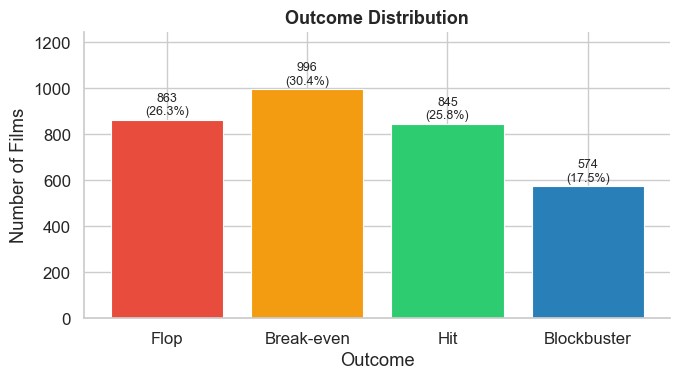

In [38]:
# Plot 1 -- Outcome distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_feat['outcome_label'].value_counts()[outcome_order]
bars = ax.bar(outcome_order, counts.values,
              color=[OUTCOME_COLORS[o] for o in outcome_order],
              edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts.values):
    pct = count / len(df_feat) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Outcome Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of Films')
ax.set_ylim(0, counts.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

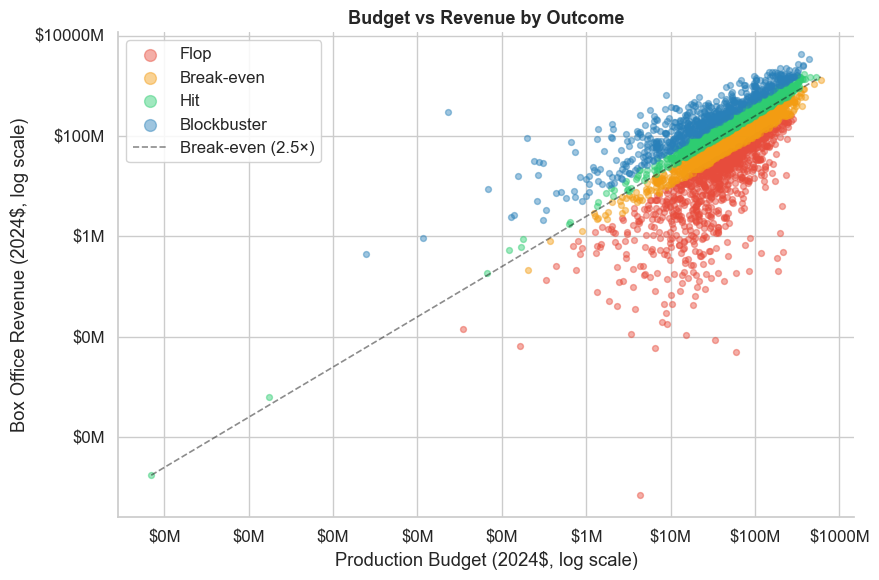

In [39]:
# Plot 2 -- Budget vs Revenue scatter (log scale, coloured by outcome)
fig, ax = plt.subplots(figsize=(9, 6))
for outcome in outcome_order:
    sub = df_feat[df_feat['outcome_label'] == outcome]
    ax.scatter(sub['budget_adj'], sub['revenue_adj'],
               c=OUTCOME_COLORS[outcome], alpha=0.45, s=18, label=outcome, rasterized=True)

# Break-even reference line (revenue = 2.5x budget)
xlim = np.array([df_feat['budget_adj'].min(), df_feat['budget_adj'].max()])
ax.plot(xlim, xlim * 2.5, 'k--', linewidth=1.2, alpha=0.5, label='Break-even (2.5×)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_xlabel('Production Budget (2024$, log scale)')
ax.set_ylabel('Box Office Revenue (2024$, log scale)')
ax.set_title('Budget vs Revenue by Outcome', fontsize=13, fontweight='bold')
ax.legend(markerscale=2, framealpha=0.85)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'budget_revenue_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

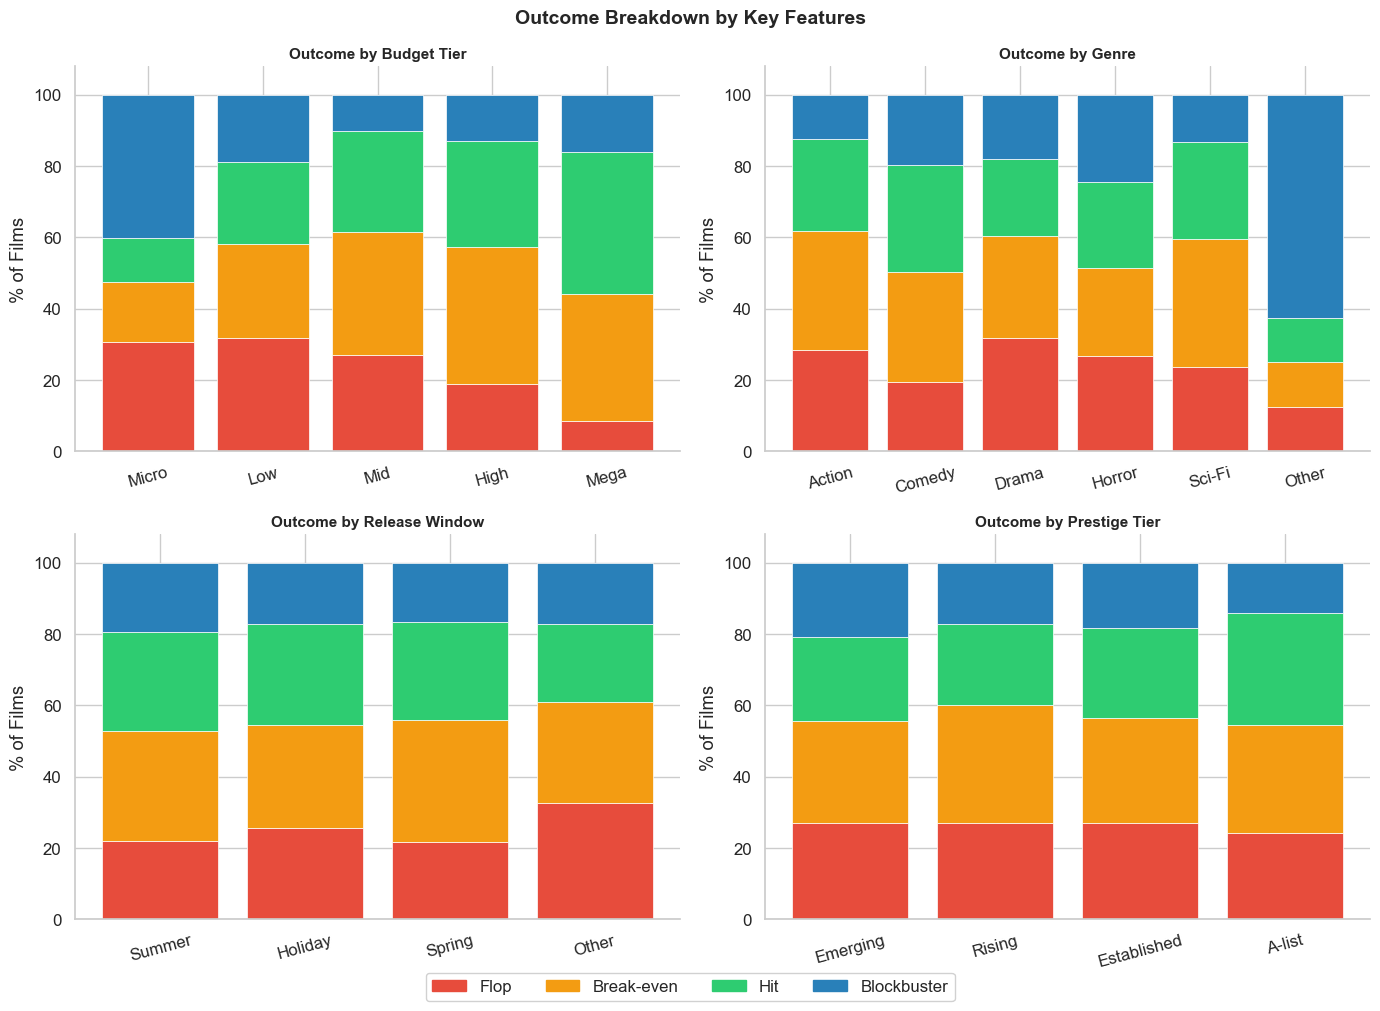

In [ ]:
# Plots 3-6 -- Outcome breakdown by budget tier, genre, release window, prestige tier
breakdown_vars = [
    ('budget_tier',    ['Micro', 'Low', 'Mid', 'High', 'Mega'],              'Outcome by Budget Tier'),
    ('genre_bn',       ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi', 'Other'], 'Outcome by Genre'),
    ('release_window', ['Summer', 'Holiday', 'Spring', 'Other'],             'Outcome by Release Window'),
    ('prestige_tier',  ['Emerging', 'Rising', 'Established', 'A-list'],      'Outcome by Prestige Tier'),
]

#Holiday = November + December (Thanksgiving, Christmas, New Year's window)
#Summer = June, July, August (blockbuster season)
#Spring = March, April, May (shoulder season)
#Other = January, February, September, October (the "dump months" — studios typically release weaker films here)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, cat_order, title) in zip(axes.flat, breakdown_vars):
    ct = pd.crosstab(df_feat[col], df_feat['outcome_label'])
    ct = ct.reindex(index=[x for x in cat_order if x in ct.index],
                    columns=outcome_order, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(ct_pct))
    for outcome in outcome_order:
        if outcome in ct_pct.columns:
            ax.bar(ct_pct.index, ct_pct[outcome], bottom=bottom,
                   color=OUTCOME_COLORS[outcome], label=outcome,
                   edgecolor='white', linewidth=0.5)
            bottom += ct_pct[outcome].values
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Films')
    ax.set_ylim(0, 108)
    ax.tick_params(axis='x', rotation=15)
    sns.despine(ax=ax)

handles = [mpatches.Patch(color=OUTCOME_COLORS[o], label=o) for o in outcome_order]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.9)
plt.suptitle('Outcome Breakdown by Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'outcome_breakdowns.png', dpi=150, bbox_inches='tight')
plt.show()

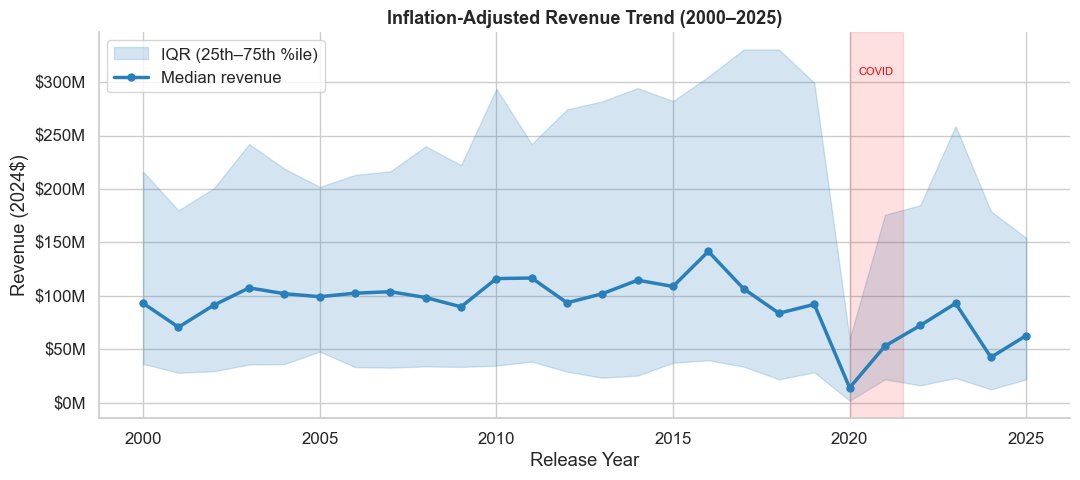

In [41]:
# Plot 7 -- Inflation-adjusted revenue trend 2000-2025
yearly = df_feat.groupby('release_year').agg(
    median_rev=('revenue_adj', 'median'),
    q25_rev=('revenue_adj', lambda x: x.quantile(0.25)),
    q75_rev=('revenue_adj', lambda x: x.quantile(0.75)),
).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(yearly['release_year'], yearly['q25_rev'] / 1e6, yearly['q75_rev'] / 1e6,
                alpha=0.2, color='#2980b9', label='IQR (25th–75th %ile)')
ax.plot(yearly['release_year'], yearly['median_rev'] / 1e6,
        color='#2980b9', linewidth=2.5, marker='o', markersize=5, label='Median revenue')
ax.axvspan(2020, 2021.5, alpha=0.12, color='red')
ax.text(2020.75, yearly['q75_rev'].max() / 1e6 * 0.93, 'COVID', ha='center', fontsize=8, color='red')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_xlabel('Release Year')
ax.set_ylabel('Revenue (2024$)')
ax.set_title('Inflation-Adjusted Revenue Trend (2000–2025)', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 - Bayesian Network

In [46]:
# Prepare BN dataset -- select 5 variables, drop NAs, cast to string for pgmpy
BN_COLS = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']

if 'df_feat' not in dir() or df_feat is None:
    df_feat = pd.read_csv(FEAT_PATH)
    print(f'Loaded {len(df_feat)} rows from {FEAT_PATH}')

df_bn = df_feat[BN_COLS].dropna().astype(str)
print(f'BN dataset: {len(df_bn)} rows × {len(BN_COLS)} variables')
print('\nVariable states:')
for col in BN_COLS:
    states = sorted(df_bn[col].unique())
    print(f'  {col:<20} {states}')

BN dataset: 3278 rows × 5 variables

Variable states:
  prestige_tier        ['A-list', 'Emerging', 'Established', 'Rising']
  genre_bn             ['Action', 'Comedy', 'Drama', 'Horror', 'Other', 'Sci-Fi']
  release_window       ['Holiday', 'Other', 'Spring', 'Summer']
  budget_tier          ['High', 'Low', 'Mega', 'Micro', 'Mid']
  outcome_label        ['Blockbuster', 'Break-even', 'Flop', 'Hit']


In [47]:
# PC algorithm finds statistically supported dependencies (undirected skeleton)
# Domain knowledge then orients every edge causally
BN_COLS = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']
df_bn = df_feat[BN_COLS].dropna().astype(str)
print(f'BN dataset: {len(df_bn)} rows × {len(BN_COLS)} variables')

pc = PC(df_bn)
skeleton, _ = pc.estimate(
    variant='stable', ci_test='chi_square',
    significance_level=0.05, return_type='skeleton', show_progress=False
)
print('\nPC skeleton edges (undirected):')
for e in sorted(skeleton.edges()):
    print(f'  {e[0]}  --  {e[1]}')

# Domain-knowledge orientation
# prestige → genre/budget choice (A-list actors pick bigger projects)
# genre    → budget commitment, release timing
# release  → budget scale (summer/holiday = bigger spend)
# budget   → outcome (scale drives reach)
HYBRID_EDGES = [
    ('prestige_tier',  'genre_bn'),
    ('prestige_tier',  'budget_tier'),
    ('prestige_tier',  'outcome_label'),
    ('genre_bn',       'budget_tier'),
    ('genre_bn',       'outcome_label'),
    ('genre_bn',       'release_window'),
    ('release_window', 'budget_tier'),
    ('budget_tier',    'outcome_label'),
]
model = DiscreteBayesianNetwork(HYBRID_EDGES)
print('\nHybrid DAG edges (domain-oriented):')
for e in model.edges():
    print(f'  {e[0]}  →  {e[1]}')

BN dataset: 3278 rows × 5 variables

PC skeleton edges (undirected):
  budget_tier  --  outcome_label
  genre_bn  --  budget_tier
  genre_bn  --  outcome_label
  genre_bn  --  release_window
  prestige_tier  --  budget_tier
  prestige_tier  --  genre_bn
  release_window  --  budget_tier

Hybrid DAG edges (domain-oriented):
  prestige_tier  →  genre_bn
  prestige_tier  →  budget_tier
  prestige_tier  →  outcome_label
  genre_bn  →  budget_tier
  genre_bn  →  outcome_label
  genre_bn  →  release_window
  budget_tier  →  outcome_label
  release_window  →  budget_tier


PC confirmed 7 of 8 edges; the prestige→outcome direct edge was added by domain knowledge, suggesting prestige primarily operates through budget and genre selection rather than as an independent outcome driver

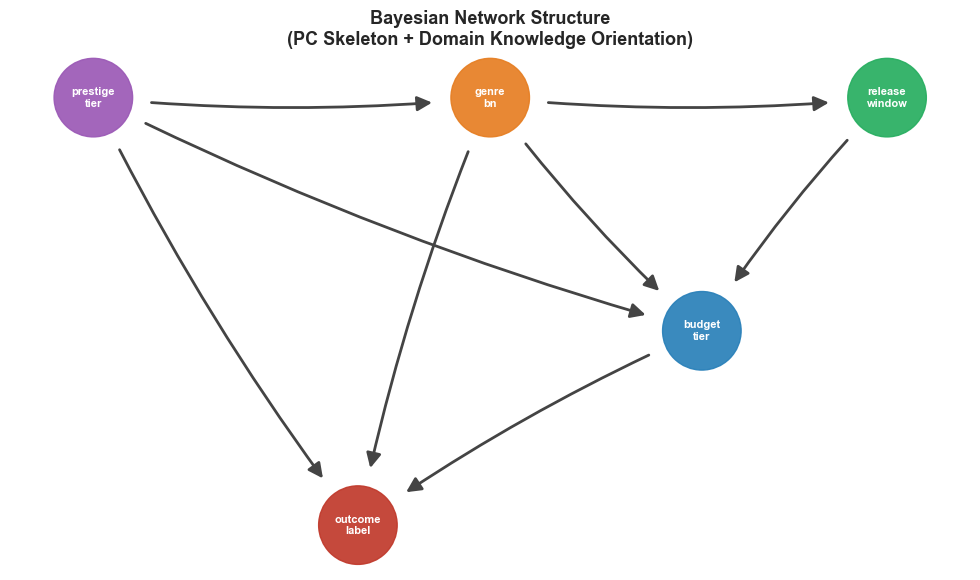

In [48]:
# Visualise the DAG
NODE_COLORS = {
    'prestige_tier':  '#9b59b6',
    'genre_bn':       '#e67e22',
    'release_window': '#27ae60',
    'budget_tier':    '#2980b9',
    'outcome_label':  '#c0392b',
}
pos = {
    'prestige_tier':  (-1.5,  1.0),
    'genre_bn':       ( 0.0,  1.0),
    'release_window': ( 1.5,  1.0),
    'budget_tier':    ( 0.8, -0.2),
    'outcome_label':  (-0.5, -1.2),
}

fig, ax = plt.subplots(figsize=(10, 6))
G = nx.DiGraph(model.edges())
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[NODE_COLORS[n] for n in G.nodes()],
    node_size=3200, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax,
    labels={n: n.replace('_', '\n') for n in G.nodes()},
    font_size=8, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color='#444444', arrows=True, arrowsize=22,
    arrowstyle='-|>', width=2.0,
    connectionstyle='arc3,rad=0.05',
    min_source_margin=42, min_target_margin=42)
ax.set_title('Bayesian Network Structure\n(PC Skeleton + Domain Knowledge Orientation)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'bayesian_network_dag.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# Fit CPDs using Maximum Likelihood Estimation
model.fit(df_bn, estimator=MaximumLikelihoodEstimator)
print('CPDs fitted successfully.')
print(f'Nodes: {list(model.nodes())}')
print(f'Edges: {list(model.edges())}')

CPDs fitted successfully.
Nodes: ['prestige_tier', 'genre_bn', 'budget_tier', 'outcome_label', 'release_window']
Edges: [('prestige_tier', 'genre_bn'), ('prestige_tier', 'budget_tier'), ('prestige_tier', 'outcome_label'), ('genre_bn', 'budget_tier'), ('genre_bn', 'outcome_label'), ('genre_bn', 'release_window'), ('budget_tier', 'outcome_label'), ('release_window', 'budget_tier')]


In [50]:
# Model validation + readable CPD summary
print(f'Model valid: {model.check_model()}')
total_params = sum(cpd.get_values().size for cpd in model.cpds)
print(f'Total parameters: {total_params}')

# Root node -- marginal P(prestige_tier)
print('\n--- P(prestige_tier) ---')
print(model.get_cpds('prestige_tier'))

# P(release_window | genre_bn) -- one parent, compact and readable
print('\n--- P(release_window | genre_bn) ---')
print(model.get_cpds('release_window'))

Model valid: True
Total parameters: 1012

--- P(prestige_tier) ---
+----------------------------+----------+
| prestige_tier(A-list)      | 0.251373 |
+----------------------------+----------+
| prestige_tier(Emerging)    | 0.248322 |
+----------------------------+----------+
| prestige_tier(Established) | 0.248627 |
+----------------------------+----------+
| prestige_tier(Rising)      | 0.251678 |
+----------------------------+----------+

--- P(release_window | genre_bn) ---
+-------------------------+-----+---------------------+
| genre_bn                | ... | genre_bn(Sci-Fi)    |
+-------------------------+-----+---------------------+
| release_window(Holiday) | ... | 0.18226600985221675 |
+-------------------------+-----+---------------------+
| release_window(Other)   | ... | 0.33497536945812806 |
+-------------------------+-----+---------------------+
| release_window(Spring)  | ... | 0.22660098522167488 |
+-------------------------+-----+---------------------+
| release_win

## Section 6 - Probabilistic Inference

In [51]:
# Variable Elimination engine + query helper
infer = VariableElimination(model)

def query_outcome(evidence):
    res    = infer.query(['outcome_label'], evidence=evidence, show_progress=False)
    states = res.state_names['outcome_label']
    return {s: float(v) for s, v in zip(states, res.values)}

print('Variable Elimination engine ready.')

Variable Elimination engine ready.


In [52]:
# Single-variable marginal queries -- isolate effect of each feature
print('=== Prestige Tier Effect ===')
for tier in ['Emerging', 'Rising', 'Established', 'A-list']:
    probs = query_outcome({'prestige_tier': tier})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {tier:<14}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Budget Tier Effect ===')
for tier in ['Micro', 'Low', 'Mid', 'High', 'Mega']:
    probs = query_outcome({'budget_tier': tier})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {tier:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Genre Effect ===')
for genre in ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi']:
    probs = query_outcome({'genre_bn': genre})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {genre:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Release Window Effect ===')
for window in ['Summer', 'Holiday', 'Spring', 'Other']:
    probs = query_outcome({'release_window': window})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {window:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

=== Prestige Tier Effect ===
  Emerging        P(Blockbuster)=0.207  P(Flop)=0.271
  Rising          P(Blockbuster)=0.171  P(Flop)=0.271
  Established     P(Blockbuster)=0.182  P(Flop)=0.270
  A-list          P(Blockbuster)=0.141  P(Flop)=0.243

=== Budget Tier Effect ===
  Micro     P(Blockbuster)=0.402  P(Flop)=0.308
  Low       P(Blockbuster)=0.188  P(Flop)=0.318
  Mid       P(Blockbuster)=0.102  P(Flop)=0.272
  High      P(Blockbuster)=0.130  P(Flop)=0.188
  Mega      P(Blockbuster)=0.160  P(Flop)=0.086

=== Genre Effect ===
  Action    P(Blockbuster)=0.124  P(Flop)=0.285
  Comedy    P(Blockbuster)=0.197  P(Flop)=0.195
  Drama     P(Blockbuster)=0.178  P(Flop)=0.318
  Horror    P(Blockbuster)=0.243  P(Flop)=0.268
  Sci-Fi    P(Blockbuster)=0.134  P(Flop)=0.237

=== Release Window Effect ===
  Summer    P(Blockbuster)=0.173  P(Flop)=0.248
  Holiday   P(Blockbuster)=0.167  P(Flop)=0.256
  Spring    P(Blockbuster)=0.174  P(Flop)=0.254
  Other     P(Blockbuster)=0.182  P(Flop)=0.285


In [53]:
# Business-relevant multi-variable scenario queries
scenarios = [
    ('A-list + Mega',                  {'prestige_tier': 'A-list',     'budget_tier': 'Mega'}),
    ('A-list + Action + Summer',       {'prestige_tier': 'A-list',     'genre_bn': 'Action',  'release_window': 'Summer'}),
    ('A-list + Action + Mega + Summer',{'prestige_tier': 'A-list',     'genre_bn': 'Action',  'budget_tier': 'Mega',  'release_window': 'Summer'}),
    ('Emerging + Drama + Low + Other', {'prestige_tier': 'Emerging',   'genre_bn': 'Drama',   'budget_tier': 'Low',   'release_window': 'Other'}),
    ('Emerging + Micro',               {'prestige_tier': 'Emerging',   'budget_tier': 'Micro'}),
    ('Established + Horror + Holiday', {'prestige_tier': 'Established','genre_bn': 'Horror',  'release_window': 'Holiday'}),
]

print('=== Multi-Variable Scenario Analysis ===')
for label, evidence in scenarios:
    probs = query_outcome(evidence)
    print(f'\n{label}')
    for outcome in outcome_order:
        bar = '█' * int(probs.get(outcome, 0) * 25)
        print(f'  {outcome:<12} {probs.get(outcome, 0):.3f}  {bar}')
    print(f'  → MAP: {max(probs, key=probs.get)}')

# MAP query for the "ideal blockbuster" profile
map_result = infer.map_query(
    ['outcome_label'],
    evidence={'prestige_tier': 'A-list', 'genre_bn': 'Action',
              'budget_tier': 'Mega',     'release_window': 'Summer'},
    show_progress=False
)
print(f'\nMAP prediction (A-list + Action + Mega + Summer): {map_result["outcome_label"]}')

=== Multi-Variable Scenario Analysis ===

A-list + Mega
  Flop         0.086  ██
  Break-even   0.229  █████
  Hit          0.469  ███████████
  Blockbuster  0.216  █████
  → MAP: Hit

A-list + Action + Summer
  Flop         0.207  █████
  Break-even   0.292  ███████
  Hit          0.378  █████████
  Blockbuster  0.123  ███
  → MAP: Hit

A-list + Action + Mega + Summer
  Flop         0.076  █
  Break-even   0.167  ████
  Hit          0.530  █████████████
  Blockbuster  0.227  █████
  → MAP: Hit

Emerging + Drama + Low + Other
  Flop         0.338  ████████
  Break-even   0.300  ███████
  Hit          0.225  █████
  Blockbuster  0.138  ███
  → MAP: Flop

Emerging + Micro
  Flop         0.309  ███████
  Break-even   0.133  ███
  Hit          0.138  ███
  Blockbuster  0.420  ██████████
  → MAP: Blockbuster

Established + Horror + Holiday
  Flop         0.382  █████████
  Break-even   0.156  ███
  Hit          0.210  █████
  Blockbuster  0.251  ██████
  → MAP: Flop

MAP prediction (A-list 

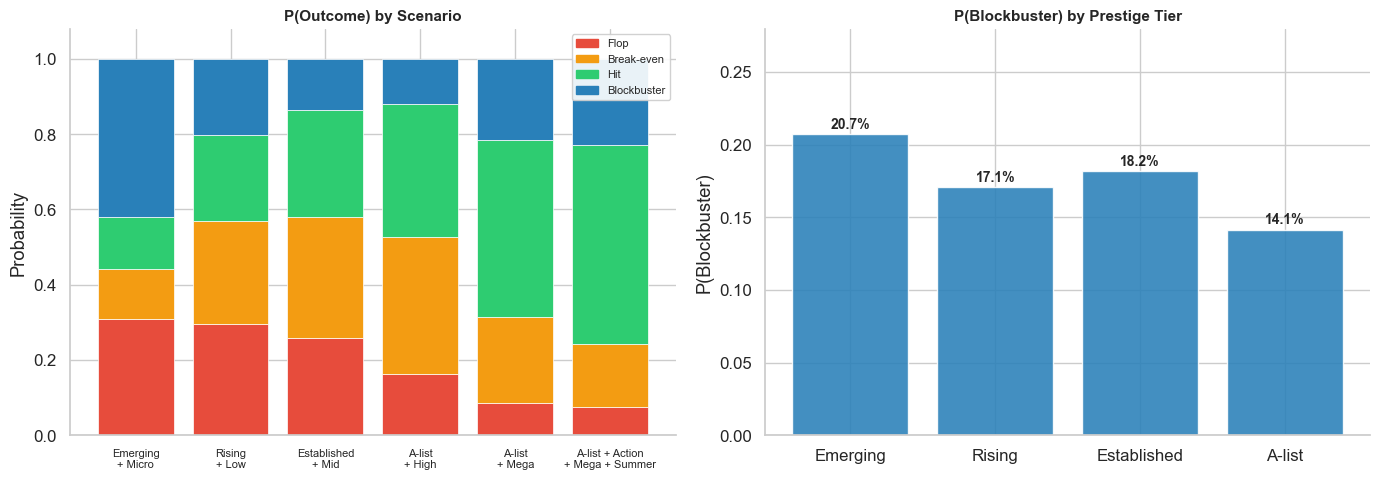

In [54]:
# Inference visualisation
scenarios_viz = {
    'Emerging\n+ Micro':                {'prestige_tier': 'Emerging',    'budget_tier': 'Micro'},
    'Rising\n+ Low':                    {'prestige_tier': 'Rising',      'budget_tier': 'Low'},
    'Established\n+ Mid':               {'prestige_tier': 'Established', 'budget_tier': 'Mid'},
    'A-list\n+ High':                   {'prestige_tier': 'A-list',      'budget_tier': 'High'},
    'A-list\n+ Mega':                   {'prestige_tier': 'A-list',      'budget_tier': 'Mega'},
    'A-list + Action\n+ Mega + Summer': {'prestige_tier': 'A-list',      'genre_bn': 'Action',
                                         'budget_tier': 'Mega',          'release_window': 'Summer'},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full stacked outcome probability per scenario
labels = list(scenarios_viz.keys())
data = {o: [] for o in outcome_order}
for ev in scenarios_viz.values():
    probs = query_outcome(ev)
    for o in outcome_order:
        data[o].append(probs.get(o, 0))

bottom = np.zeros(len(labels))
for outcome in outcome_order:
    axes[0].bar(labels, data[outcome], bottom=bottom,
                color=OUTCOME_COLORS[outcome], label=outcome, edgecolor='white', linewidth=0.5)
    bottom += np.array(data[outcome])
axes[0].set_title('P(Outcome) by Scenario', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1.08)
axes[0].tick_params(axis='x', labelsize=8)
handles = [mpatches.Patch(color=OUTCOME_COLORS[o], label=o) for o in outcome_order]
axes[0].legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)
sns.despine(ax=axes[0])

# Right: P(Blockbuster) by prestige tier
tiers    = ['Emerging', 'Rising', 'Established', 'A-list']
bb_probs = [query_outcome({'prestige_tier': t}).get('Blockbuster', 0) for t in tiers]
bars = axes[1].bar(tiers, bb_probs,
                   color=OUTCOME_COLORS['Blockbuster'], edgecolor='white', alpha=0.88)
for bar, p in zip(bars, bb_probs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                 f'{p:.1%}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('P(Blockbuster) by Prestige Tier', fontsize=11, fontweight='bold')
axes[1].set_ylabel('P(Blockbuster)')
axes[1].set_ylim(0, max(bb_probs) * 1.35)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'inference_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 - Model Comparison

## Section 8 - Sensitivity Analysis

## Section 9 - Conclusion